# Interpretability Tests

This notebook performs tests on the functions found in `my_interpretability.py`. For that it uses the `v2.0` regressor and a simple single-layer model to generate the data.

Experiments are reproducible by running the notebook, though random numbers are used to generate the data so results can slightly vary.

In [1]:
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

# Library imports
import torch
import matplotlib.pyplot as plt
torch.set_printoptions(sci_mode=False)

In [ ]:
# Import necessary utilities from my_small_PFN
from scripts.my_small_PFN import MyRegressorPFN

# Import necessary utilities from my_interpretability
from scripts.my_interpretability import FeatureEffects, FeatureImportance, DataValuation

# Create a model with the trained weights
model = MyRegressorPFN("v2.0")

Model config' correctly loaded from C:\Users\PC\Desktop\My-Small-PFN\weights\v2.0\my_PFN_config.json
Model weights correctly loaded from C:\Users\PC\Desktop\My-Small-PFN\weights\v2.0\my_PFN_weights.pth


## $X\to y$ Function With Noise

For these experiments we will consider a simple linear transformation with ReLU.

Feel free to change the generator function `transf()` and re-run the experiments to study different results.

In [3]:
# Dimensions
train_size = 256
features = 8

# Create a random set of features
X_train = torch.randn([train_size, features])

# Create a random transformation from x to y
linear = torch.randn([7,])
transf = lambda x: torch.relu(x[...,:7] * linear).sum(dim=-1, keepdim=True)

# Establish a noise function for the output
noise_std = 0.5
noise_func = lambda: torch.randn([train_size, 1]) * noise_std

# Apply and add noise
train_noise = noise_func()
y_train = transf(X_train) + train_noise

# Normalize
mean = y_train.mean(dim=0)
std = y_train.std(dim=0)
y_train = (y_train-mean)/std
norm_transf = lambda x: (transf(x) - mean) / std

# Print necessary information
print(f"Dummy train split generated with {train_size} rows and {features} features.")

Dummy train split generated with 256 rows and 8 features.


## Individual Conditional Expectation (ICE)

ICE studies how a feature value affects a prediction on particular test cases.

For this particular experiment we consider a linear set of values for the first feature and plot the ICE output. Then compare it to the original `transf` normalized without noise.

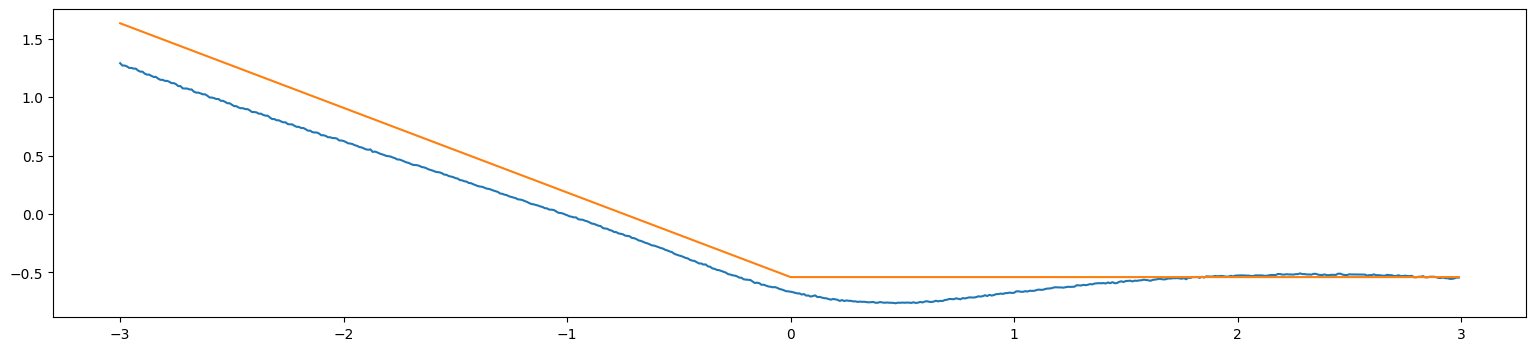

In [ ]:
# Generate a random test example
test = torch.randn([1, features])

# Consider a grid of values
K = 600
grid = [-3.0 + k / 100 for k in range(K)]

# Evaluate first feature ICE on all the values
preds = FeatureEffects.individual_conditional_expectation(model, X_train, y_train, test, feature=0, grid_values=grid)

# Calculate expected output
tensor = test.repeat(K, 1)
for k, val in enumerate(grid):
    tensor[k, 0] = val
out = norm_transf(tensor)

# Plot 
plt.figure(figsize=(19, 4))
plt.plot(grid, preds.squeeze(0))
plt.plot(grid, out)
plt.show()


## Partial Dependence (PD)

PD studies how a feature value affects the model's predictions on average across multiple test cases. It is simply an ICE function averaged.

This repeats the same experiment as the ICE case but for 32 test examples, therefore the output behavior is more stable.

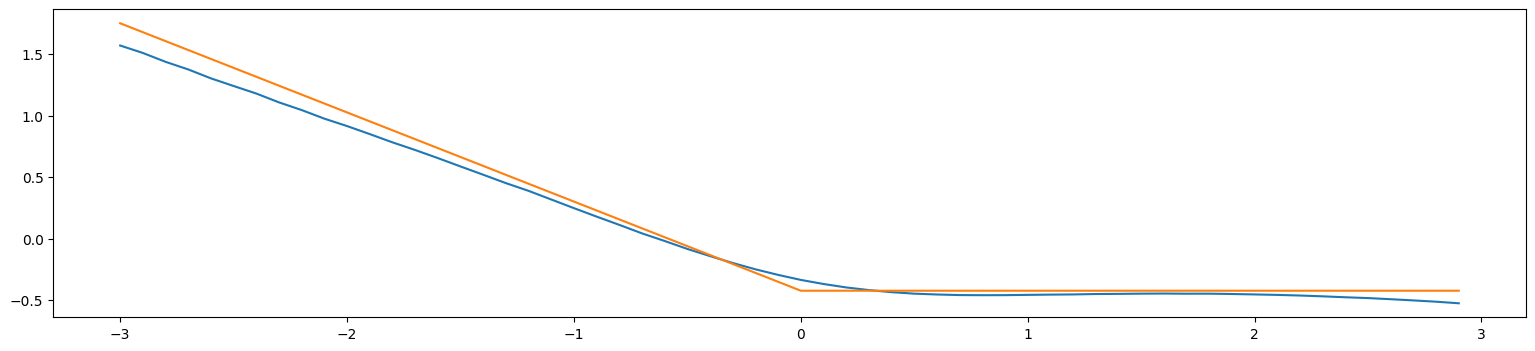

In [ ]:
# Generate a random test example
test = torch.randn([32, features])

# Consider a grid of values
K = 60
grid = [-3.0 + k / 10 for k in range(K)]

# Evaluate first feature PD
preds = FeatureEffects.partial_dependence(model, X_train, y_train, test, feature=0, grid_values=grid)

# Calculate expected output
tensor = test.unsqueeze(0).repeat(K, 1, 1)
for k, val in enumerate(grid):
    tensor[k, :, 0] = val
out = norm_transf(tensor).mean(dim=1)

# Plot 
plt.figure(figsize=(19, 4))
plt.plot(grid, preds.squeeze(0))
plt.plot(grid, out)
plt.show()

## Accumulated Local Effect (ALE)

ALE intends to solve a big problem of PD, namely it can lead to impossible feature combinations if these are not independent, giving incorrect readings.

ALE solves this by considering the effects only on the local neighborhood of each test example, with the downside of requiring more test examples than PD.

Unfortunately for our given example this method is not meaningful, since all feature value combinations are possible, but we can still showcase it with the same experiment.

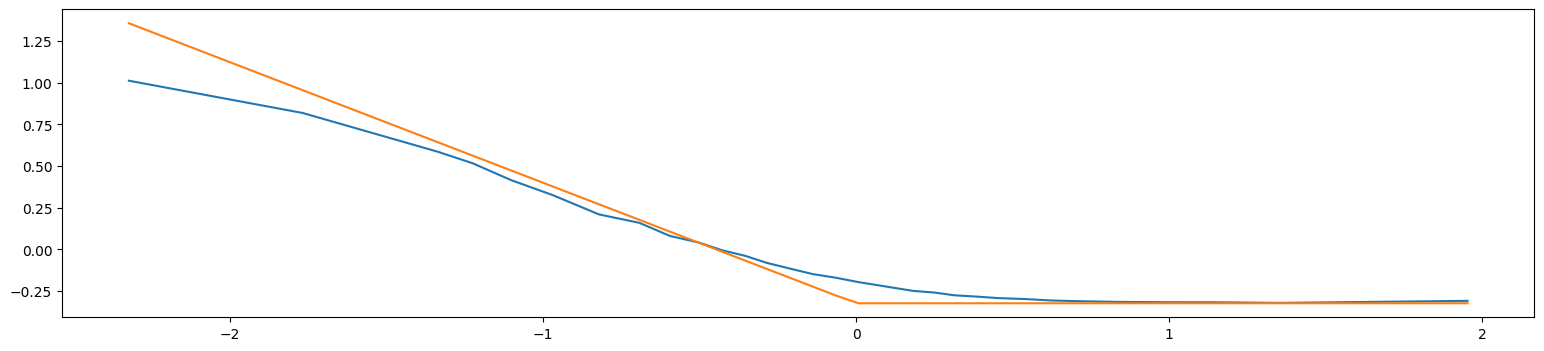

In [ ]:
# Generate a random test example
test = torch.randn([256, features])

# Set an amout of bins
K = 32

# Evaluate first feature PD
bins, preds = FeatureEffects.accumulated_local_effect(model, X_train, y_train, test, feature=0, bins=K)

# Calculate expected output
tensor = test.unsqueeze(0).repeat(K, 1, 1)
for k, val in enumerate(bins):
    tensor[k, :, 0] = val
out = norm_transf(tensor).mean(dim=1)

# Plot 
plt.figure(figsize=(19, 4))
plt.plot(bins, preds.squeeze(0))
plt.plot(bins, out-out.mean())
plt.show()

## Leave One Covariate Out (LOCO)

LOCO studies how removing a single feature affects the predictions MSE. This is done by literally removing the feature and computing the MSE difference across the test set.

Here we run the LOCO function and compare the scores to the ones obtained by directly measuring how each feature affects the target variance. Obtaining quite promising results.

In [ ]:
# Generate a random test example
test = torch.randn([256, features])

# Get correct prediction
y_test = norm_transf(test)

# Evaluate feature LOCO scores
loco_scores = FeatureImportance.leave_one_covariate_out(model, X_train, y_train, test, y_test)

# Print scores
print("LOCO scores:", -loco_scores)

# Print expected values to compare.
# To compute expected values generate a random set of input values 
# for each feature and see what the output variance is. In a perfect
# predictor that should mimic how the uncertainty of not having a 
# feature affects the output MSE, exactly LOCO.
test = test.unsqueeze(0).unsqueeze(0).repeat(features,256,1,1)
values = torch.randn([256,256])

for feat in range(features):
    test[feat,:,:, feat] = values
out = norm_transf(test)
true_scores = -out.squeeze(-1).var(dim=1).mean(dim=1)
print("True scores:", true_scores)

LOCO scores: tensor([-0.1840,  0.0008, -0.1023, -0.0015, -0.3112, -0.1504, -0.2724,  0.0043])
True scores: tensor([-0.1771, -0.0004, -0.1047, -0.0076, -0.3122, -0.1309, -0.2318, -0.0000])


## Kernel SHAP

Kernel SHAP studies how a single test case is built, this is done by considering that any test case can be decomposed as a sum of individual feature contributions.

This method computes those contributions by considering random feature configurations and linearly solving for the individual contributions that fit the observed predictions.

We compare that to the expected output, which is obtained by considering the average output obtained by removing a feature, and subtracting it from the correct output, giving us individual feature contribution.

In [ ]:
# Generate a random test example
test = torch.randn([features])

# Evaluate feature SHAP values
shap = FeatureImportance.kernel_shap(model, X_train, y_train, test)

# Print scores
print("SHAP values:", shap, f"| Predicted output: {model.fit(X_train, y_train).predict(test, output='mean'):.2f}")

# Print expected values to compare.
# To copute expected values we generate a random set of input values
# for each feature and see what the mean is for this particular case.
# If we subtract the mean from this case's output we get each feature
# contribution to this output (not exactly SHAP but close).
correct_out = norm_transf(test).item()
test = test.unsqueeze(0).unsqueeze(0).repeat(features,256,1)
values = torch.randn([256])

for feat in range(features):
    test[feat, :, feat] = values

out = norm_transf(test)
true_values = correct_out - out.mean(dim=1).squeeze(-1)
print("True values:", true_values, f"| Correct output:   {correct_out:.2f}")

SHAP values: tensor([ 0.3394, -0.3316, -0.0346, -0.2178,  0.0094, -0.0191, -0.0671, -0.0578]) | Predicted output: -0.37
True values: tensor([ 0.4381, -0.5457, -0.0743, -0.1572, -0.0499, -0.0043, -0.0506,  0.0000]) | Correct output:   -0.43


## Leave One Out (LOO)

LOO considers how much a particular training example contributes to the model predictive performance. 

This is done by literally removing the training example, running a forward pass and comparing the MSE obtained to the one with the full dataset.

This gives us a score for all the data points, in this case we remove the 10% worst scored training samples and see if MSE decreases on a separate from the one tested.

In [ ]:
# Generate a random test set
X_test = torch.randn([train_size, features])
y_test = (transf(X_test) + noise_func() - mean) / std

# Evaluate train example scores
scores = DataValuation.leave_one_out(model, X_train, y_train, X_test, y_test)

# Select the lowest scoring decile of the train set and discard it
mask = torch.ones(train_size, dtype=torch.bool)
mask[torch.argsort(scores)[:train_size//10]] = False

LOO_X_train = X_train[mask]
LOO_y_train = y_train[mask]

# Generate another test set for the comparisson
X_test = torch.randn([train_size, features])
y_test = (transf(X_test) + noise_func() - mean) / std

# Test both sets to see if we have an improvement on a different test set
mse = lambda preds: torch.mean((preds - y_test.flatten()) ** 2)

old_mse = mse(model.fit(X_train, y_train).predict(X_test, output='mean')).item()
new_mse = mse(model.fit(LOO_X_train, LOO_y_train).predict(X_test, output='mean')).item()

print(f"Old MSE: {old_mse:.4f}")
print(f"New MSE: {new_mse:.4f}")

Old MSE: 0.1671
New MSE: 0.1542


## Data Shapley

Data Shapley has the same intent as LOO but considers a different approach. It considers all possible combinations of training samples, and computes single sample contributions based on that.

Since this is very computationally expensive it heavily approximates it, which can significantly decrease accuracy.

With enough permutations this method is more stable than LOO, but given computation limitations in our case it is not as well behaved.

We run the same experiment as above, obtaining mixed results.

In [ ]:
# Generate a random test set
X_test = torch.randn([train_size, features])
y_test = (transf(X_test) + noise_func() - mean) / std

# Evaluate train example scores
scores = DataValuation.data_shapley(model, X_train, y_train, X_test, y_test)

# Select the lowest scoring decile of the train set and discard it
mask = torch.ones(train_size, dtype=torch.bool)
mask[torch.argsort(scores)[:train_size//10]] = False

Shapley_X_train = X_train[mask]
Shapley_y_train = y_train[mask]

# Generate another test set for the comparisson
X_test = torch.randn([train_size, features])
y_test = (transf(X_test) + noise_func() - mean) / std

# Test both sets to see if we have an improvement on a different test set
mse = lambda preds: torch.mean((preds - y_test.flatten()) ** 2)

old_mse = mse(model.fit(X_train, y_train).predict(X_test, output='mean')).item()
new_mse = mse(model.fit(Shapley_X_train, Shapley_y_train).predict(X_test, output='mean')).item()

print(f"Old MSE: {old_mse:.4f}")
print(f"New MSE: {new_mse:.4f}")

Old MSE: 0.1463
New MSE: 0.1390
